## Scraping Agents Workflow Architecture Prototyping 

The main agents that will be tested are going to be: 
- Item Selection Agent: chooses which listings may be valid and worth investigating, selects like 3-9 listings, and then 1-3 are chosen and the rest are used as backup in case the listings researched were invalid.
- Orchestrator Agent: When given a listing deemed worthy of investigating, coordinates and monitors spawned sub-agents, collects their findings and flagged ambiguities, and delivers a final buy/watch/ignore verdict with reasoning.
- eBay Sub-Agent: Searches eBay for sold listings matching the given item, normalizes results against the source listing (title, condition, colorway, year where available), flags ambiguous matches, and returns structured comp data to the orchestrator.

## Agent-To-Agent-Interactions 
Item Selection <--> Item Selection: 
- only interacts with itself, and once the listings are found, the data is stored and gone through sequentially, spawning one orchestrator agent at at time. 

Orchestrator -> eBay: 
- resolves eBay listing confusion
- monitors sub-agents(can pause, stop, or kill a sub-agent) 

eBay -> Orchestrator: 
- flags eBay listing and calls Orchestrator agent to help resolve confusion

# Agent Inputs 
Item Selection: 
- structured/parsed html from TheRealReal brand catalog page 

Orchestrator: 
- all info pertaining to a given listing, use schemas/models based on the category of the garment 
- eBay flagged listing info

eBay: 
- all info pertaining to a given listing, use schemas/models based on the category of the garment 

# Agent Outputs
- TODO

# Important Data Centralizations
- All item listing info is centralized into one structure that ALL agents will use to make context injection easier. 
- All listings regardless if they are found on eBay or TheRealReal all share the same model/schema based on the type of garment(shoes, tshirt, jacket, etc). 
- 


In [ ]:
from typing import TypedDict, Annotated                                                                          
  from langgraph.graph import StateGraph                                                                           
  import operator                                                                                                  
                                                                                                                   
  class AgentState(TypedDict):                                                                                     
      listing: dict                                                                                                
      ebay_comps: list                                                                                           
      flags: Annotated[list, operator.add]  # agents append, don't overwrite
      verdict: str 

In [ ]:
 def orchestrator_node(state: AgentState):
      # reason over state, return partial update
      return {"verdict": "buy"}

  def ebay_agent_node(state: AgentState):
      return {"ebay_comps": [...], "flags": ["ambiguous colorway"]}

# Listing Selection Agent Prototype
Processes TRR listings in batches of 2, accumulates picks until quota (2) is met, then stops. Once listings are found, it may be stored either in state and/or SQLite, still TBD. Doesn't include how html is refetched, only works once there is html for a listing catalog that already exists. 

HTML FOLDER ARCHITECTURE(located inside of db/)
/html
/catalog -> vivienne_westwood_2026-06-12.html : brand_name, year, month, day
/listing ->  item_67890.html : item and a basic UUID 

- Discrete Workflow Steps for Listing Selection 

1. get_listings(brand: str) # check dir, pull html download from directory 
2. parse_html(html : str) # get x listings through regex or key-value matching(html already has structure) 
3. classify_listings() # classifies listings to filter what is worth keeping/investigating 

- Non-functional helper components, but will be needed for testing after workflow is completed  
show_selected_listings() 
show_discarded_listings() 
show_confusing_listings() 
- all of these show listing meta-data along with image and reason for classification based on the listings and their received categories

enum ClothingType:  
tshirt : str, 
jacket : str, 
dress: str, 
etc... 

Catalog Individual Listing Schema: 
name : str 
brand : str
listing_url: str 
image_url: str 
classification : {type: str, reason: str} 

** NULLABLE FIELDS ** determined by LLM and/or after a listing is classified as worth researching  
type: ClothingType(enum) # TBD by LLM after picking listings(urls show the type of item)
size : str 
description: str 
condition: str  
** except "type", all other fields are determined after the listing's detailed html is pulled after being deemed worthy to keep researching ** 

get_listings(brand : str) -> list[any]: 
- straightforward, return listings in a list of dicts 

parse_html(html : Object) -> list[any]: 
- return structured dicts based on the listings 

classify_listings(listings : any) -> list[any] 
- static context: 
- dynamic context: item info 
- takes max 3 listings and returns with classification types/reason 



In [ ]:
### HTML Parser — Layer 1: JSON-LD Collection
# Parses the structured data blob embedded in the page — gives name, url, image for 
# all listings in one shot.

from bs4 import BeautifulSoup
import json

catalog_file_name = "clean_catalog.html"

with open(f"{catalog_file_name}", "r") as f:
    soup = BeautifulSoup(f, "lxml")

# --- Step 1: parse the JSON-LD collection ---
script = soup.find("script", {"type": "application/ld+json"})
data = json.loads(script.string)

collection_name = data["name"]           # e.g. "undercover"
collection_url  = data["url"]
listings_raw    = data["mainEntity"]["itemListElement"]

print(f"Collection : {collection_name}")
print(f"URL        : {collection_url}")
print(f"Listings   : {len(listings_raw)}")


In [ ]:
from bs4 import BeautifulSoup
import json

with open(f"{catalog_file_name}", "r") as f:
  html = f.read()

  soup = BeautifulSoup(html, "lxml")

  # Target the JSON-LD script tag
  # script = soup.find("script", {"type": "application/ld+json"})
  # data = json.loads(script.string)
  print(len(html))
  print(html[:500])

  # Navigate to listings
  # listings = data["mainEntity"]["itemListElement"]
  # Each listing: {"@type": "ListItem", "position": 1, "name": "...", "url": "...", "image": "..."}


In [ ]:
import re

cards = soup.find_all("div", {"data-testid": re.compile(r"^plp-product/\d+$")})

def get_text(card, testid_suffix):
    el = card.find(attrs={"data-testid": re.compile(testid_suffix + "$")})
    return el.get_text(strip=True) if el else None

def extract_price_fields(card):
    return {
        "price_original" : get_text(card, "-price-original"),
        "price_final"    : get_text(card, "-price-final"),
        "price_callout"  : get_text(card, "-price-callout"),
    }


In [ ]:
import re

fields = ["name", "listing_url", "image_url", "size", "price_original", "price_final"]
counts = {f: 0 for f in fields}
total = min(len(cards), len(listings_raw))

for i, card in enumerate(cards[:total]):
    meta        = listings_raw[i]
    prices      = extract_price_fields(card)
    product_id  = card["data-testid"].split("/")[1]

    row = {
        "name"           : meta.get("name"),
        "listing_url"    : meta.get("url"),
        "image_url"      : meta.get("image"),
        "size"           : get_text(card, "-size"),
        "price_original" : prices["price_original"],
        "price_final"    : prices["price_final"],
    }

    for f in fields:
        if row.get(f):
            counts[f] += 1

    callout = f" ({prices['price_callout']})" if prices["price_callout"] else ""
    print(f"[{product_id}] {row['name']}")
    print(f"  size     : {row['size']}")
    print(f"  price    : {row['price_original']}")
    print(f"  final    : {row['price_final']}{callout}")
    print(f"  image    : {row['image_url']}")
    print(f"  url      : {row['listing_url']}")
    print()

print("=" * 40)
print(f"Coverage report ({total} listings)\n")
for f in fields:
    pct = (counts[f] / total * 100) if total else 0
    bar = "#" * int(pct / 5)
    print(f"  {f:<18} {pct:5.1f}%  {bar}")

In [1]:
# LangChain tool wrappers around HTMLTools.
# Tools are instance-bound (they read self.soup), so we build them from a live
# HTMLTools instance and hand the list to whichever node needs HTML access.
from langchain_core.tools import StructuredTool


def build_html_lc_tools(html_tools) -> list:
    """Wrap HTMLTools instance methods as LangChain StructuredTools.

    Pass the returned list to any LangChain/LangGraph agent that needs to
    inspect catalog HTML (e.g. the selector-healing node).
    """
    return [
        StructuredTool.from_function(
            func=html_tools.get_card_testids,
            name="get_card_testids",
            description=(
                "Return every unique data-testid value found inside one product "
                "card. Call this first to discover which testids exist before "
                "asking for their surrounding HTML."
            ),
        ),
        StructuredTool.from_function(
            func=html_tools.get_element_context,
            name="get_element_context",
            description=(
                "Return up to `limit` HTML snippets surrounding elements whose "
                "data-testid ends with `testid_suffix`. `chars` controls how "
                "many characters of context to include on each side. Use this "
                "to inspect markup around a candidate selector."
            ),
        ),
    ]


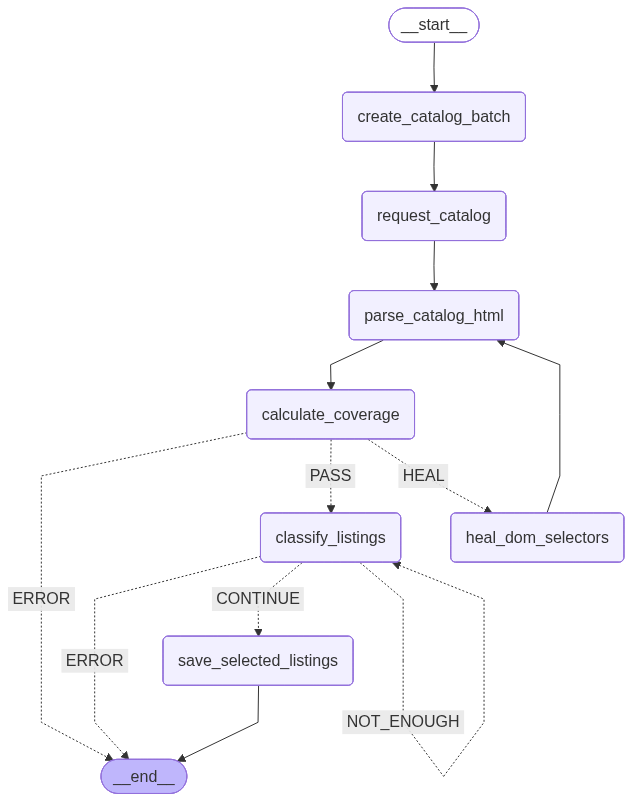

In [2]:
import os
import json
import re
from dataclasses import dataclass, field
from pathlib import Path
from typing import TypedDict, NotRequired, Optional

from langchain_core.messages import HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import create_react_agent
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image, display

# discrete steps for workflow:
# 1. create_catalog_batch  - kicks off CDP fetch via HTMLTools.generate_catalog_html, returns batch_id
# 2. request_catalog       - verifies the HTML landed on disk and resolves its path
# 3. parse_catalog_html    - delegates JSON-LD + DOM parsing to HTMLTools.clean_catalog_html
# 4. calculate_coverage    - % per field; below threshold -> heal
# 5. heal_dom_selectors    - LLM (Gemini) inspects HTML via tools, returns updated selectors
# 6. classify_listings     - pops batch of 3, LLM categorizes selected/discarded/confused
# 7. evaluate_picks        - router: quota met -> save, more needed -> loop, exhausted -> ERROR
# 8. save_selected_listings - TODO (deferred until catalog structure decisions are made)

# Ground-truth listing schema. clean_catalog_html currently returns plain dicts
# shaped like this; this dataclass exists so coverage / classification code has
# a single canonical reference for "what fields can show up on a TRR listing."
#
#  - price        = original/sticker price
#  - final_price  = sale price after discount (only present when item is on sale)
#  - size         = often missing on bags/accessories — handled specially in coverage
#  - classification = filled in later by classify_listings, not by the parser
@dataclass
class Listing:
    name: Optional[str] = None
    brand: Optional[str] = None
    listing_url: Optional[str] = None
    image_url: Optional[str] = None
    price: Optional[str] = None
    final_price: Optional[str] = None
    size: Optional[str] = None
    classification: Optional[dict] = None

    @classmethod
    def fields_for_coverage(cls) -> dict[str, float]:
        """Return {field_name: required_coverage_threshold}.

        Fields not listed here are excluded from coverage entirely
        (e.g. `size` is sparse by design, `classification` is filled later).
        """
        return {
            "name": 0.75,
            "listing_url": 0.75,
            "image_url": 0.75,
            "price": 0.75,
            "final_price": 0.40,   # only present on sale items; brand-dependent
        }

# Model used for both nodes. flash = good tool-use + JSON mode + cheap.
# Swap classify down to "gemini-2.5-flash-lite" later if cost matters.
GEMINI_MODEL = "gemini-2.5-flash"


class AgentEvals:
    """All counters/metrics for evaluating the ListingSelectionAgent live here."""
    def __init__(self):
        self.heal_calls = 0                 # times heal_dom_selectors was invoked
        self.classify_batches = 0           # total classify_listings batches run
        self.quota_retries = 0              # times classify ran beyond the first batch (quota miss)
        self.batch_results = []             # [{"selected": int, "discarded": int, "confused": int}]
        self.coverage_improvements = []     # avg-coverage delta per heal call
        self._pre_heal_coverage = None      # internal: stashed before heal, consumed after next parse

    def record_heal_start(self, coverage: dict):
        self.heal_calls += 1
        self._pre_heal_coverage = dict(coverage) if coverage else {}

    def record_post_heal_coverage(self, coverage: dict):
        if self._pre_heal_coverage is None:
            return
        before = self._pre_heal_coverage
        deltas = [coverage.get(f, 0) - before.get(f, 0) for f in before]
        if deltas:
            self.coverage_improvements.append(sum(deltas) / len(deltas))
        self._pre_heal_coverage = None

    def record_classify_batch(self, selected: int, discarded: int, confused: int):
        self.classify_batches += 1
        if self.classify_batches > 1:
            self.quota_retries += 1
        self.batch_results.append({
            "selected": selected, "discarded": discarded, "confused": confused
        })

    def avg_coverage_improvement(self) -> float:
        if not self.coverage_improvements:
            return 0.0
        return sum(self.coverage_improvements) / len(self.coverage_improvements)

    def keep_discard_ratio(self) -> float:
        kept = sum(b["selected"] for b in self.batch_results)
        discarded = sum(b["discarded"] for b in self.batch_results)
        if discarded == 0:
            return float("inf") if kept else 0.0
        return kept / discarded


class ListingSelectionState(TypedDict):
    brand: str
    worthy_listing_quota: NotRequired[int]   # defaults to 3 in code
    max_classify_batches: NotRequired[int]   # defaults to 5 in code
    batch_id: NotRequired[str]               # 5-character UUID
    scrape_config: NotRequired[dict]         # pulled from dom_config.json or healed

    listings: NotRequired[list]              # mutating queue of listing dicts
    selected_listings: NotRequired[list]
    discarded_listings: NotRequired[list]
    confused_listings: NotRequired[list]

    catalog_html_path: NotRequired[str]
    last_coverage: NotRequired[dict]         # field -> %
    selector_history: NotRequired[list]      # prev configs the healer has tried
    retries: NotRequired[int]                # heal retry counter
    failed_fields: NotRequired[list]


# store in db/html like:
# folder = brand_name, file = "{MMDDYY}_{batch_id}.html"
# helper html functions: generate_catalog_html() / check_catalog_html() inside src/scraper/tools/html.py
class ListingSelectionAgent:
    DEFAULT_QUOTA = 3
    DEFAULT_MAX_BATCHES = 5
    COVERAGE_THRESHOLD = 0.75
    HEAL_RETRY_CAP = 3

    def __init__(self, brand: str):
        self.brand = brand
        self.evals = AgentEvals()
        self._html_tools = None
        self._html_lc_tools = None
        # langchain-google-genai reads GOOGLE_API_KEY; mirror from GEMINI_API_KEY
        # so the same env var that worked for the raw SDK keeps working.
        api_key = os.environ.get("GEMINI_API_KEY") or os.environ.get("GOOGLE_API_KEY")
        if api_key:
            os.environ["GOOGLE_API_KEY"] = api_key
        self.graph = self.build_graph()

    @property
    def html_tools(self):
        # lazy import so this cell parses even if src/scraper/tools/html.py has issues
        if self._html_tools is None:
            from src.scraper.tools.html import HTMLTools
            self._html_tools = HTMLTools(self.brand)
        return self._html_tools

    @property
    def html_lc_tools(self):
        # langchain StructuredTools wrapping the live html_tools instance
        if self._html_lc_tools is None:
            self._html_lc_tools = build_html_lc_tools(self.html_tools)
        return self._html_lc_tools

    def build_graph(self):
        builder = StateGraph(ListingSelectionState)
        builder.add_node("create_catalog_batch", self.create_catalog_batch)
        builder.add_node("request_catalog", self.request_catalog)
        builder.add_node("parse_catalog_html", self.parse_catalog_html)
        builder.add_node("calculate_coverage", self.calculate_coverage)
        builder.add_node("heal_dom_selectors", self.heal_dom_selectors)
        builder.add_node("classify_listings", self.classify_listings)
        builder.add_node("save_selected_listings", self.save_selected_listings)

        builder.set_entry_point("create_catalog_batch")
        builder.add_edge("create_catalog_batch", "request_catalog")
        builder.add_edge("request_catalog", "parse_catalog_html")
        builder.add_edge("parse_catalog_html", "calculate_coverage")
        builder.add_conditional_edges("calculate_coverage", self.route_coverage, {
            "HEAL": "heal_dom_selectors",
            "PASS": "classify_listings",
            "ERROR": END,
        })
        builder.add_edge("heal_dom_selectors", "parse_catalog_html")
        builder.add_conditional_edges("classify_listings", self.evaluate_picks, {
            "NOT_ENOUGH": "classify_listings",
            "CONTINUE": "save_selected_listings",
            "ERROR": END,
        })
        builder.add_edge("save_selected_listings", END)

        return builder.compile()

    # ---------- routers ----------

    def route_coverage(self, state: ListingSelectionState) -> str:
        if state.get("retries", 0) >= self.HEAL_RETRY_CAP:
            return "ERROR"
        if state.get("failed_fields"):
            return "HEAL"
        return "PASS"

    def evaluate_picks(self, state: ListingSelectionState) -> str:
        quota = state.get("worthy_listing_quota", self.DEFAULT_QUOTA)
        max_batches = state.get("max_classify_batches", self.DEFAULT_MAX_BATCHES)
        selected = state.get("selected_listings", [])
        remaining = state.get("listings", [])

        if len(selected) >= quota:
            return "CONTINUE"
        if self.evals.classify_batches >= max_batches:
            return "ERROR"
        if not remaining:
            return "ERROR"
        return "NOT_ENOUGH"

    # ---------- nodes ----------

    async def create_catalog_batch(self, state: ListingSelectionState) -> dict:
        batch_id = await self.html_tools.generate_catalog_html(state["brand"])
        return {"batch_id": batch_id}

    def request_catalog(self, state: ListingSelectionState) -> dict:
        brand = state["brand"]
        batch_id = state["batch_id"]
        exists = self.html_tools.check_catalog_html(brand, batch_id)
        if not exists:
            raise RuntimeError(f"Catalog HTML not found for {brand}/{batch_id}")
        path = self.html_tools.get_catalog_html_path(brand, batch_id)
        return {"catalog_html_path": str(path)}

    def parse_catalog_html(self, state: ListingSelectionState) -> dict:
        if state.get("scrape_config"):
            self.html_tools.config = state["scrape_config"]
        listings = self.html_tools.clean_catalog_html(state["brand"], state["batch_id"])
        return {"listings": listings}

    def calculate_coverage(self, state: ListingSelectionState) -> dict:
        listings = state.get("listings", [])
        total = len(listings)
        # Per-field thresholds come from the Listing dataclass — size is
        # intentionally absent (sparse), final_price has a lower bar since
        # it only exists when an item is discounted.
        thresholds = Listing.fields_for_coverage()
        coverage = {}
        failed = []
        for f, threshold in thresholds.items():
            count = sum(1 for l in listings if l.get(f))
            pct = count / total if total else 0
            coverage[f] = pct
            if pct < threshold:
                failed.append(f)

        # if we just came back from a heal, record the delta
        self.evals.record_post_heal_coverage(coverage)

        return {"last_coverage": coverage, "failed_fields": failed}

    def heal_dom_selectors(self, state: ListingSelectionState) -> dict:
        last_coverage = state.get("last_coverage", {})
        selector_history = state.get("selector_history", [])
        current_config = state.get("scrape_config") or self.html_tools.config

        self.evals.record_heal_start(last_coverage)

        goal_prompt = (
            "You are healing broken DOM selectors for a TheRealReal catalog scraper. "
            "Inspect the HTML using the available tools and return an updated "
            "scrape_config JSON with selectors that improve field coverage."
        )
        tool_context = (
            "Tools available: "
            "get_card_testids() -> list[str], "
            "get_element_context(testid_suffix: str, chars: int, limit: int) -> list[str]"
        )
        dynamic_context = json.dumps({
            "current_config": current_config,
            "last_coverage": last_coverage,
            "failed_fields": state.get("failed_fields", []),
            "selector_history": selector_history,
        }, indent=2)
        full_prompt = f"{goal_prompt}\n\n{tool_context}\n\nState:\n{dynamic_context}"

        # heal_dom_selectors gets the full html toolset; create_react_agent runs
        # the tool-call loop for us until the model returns a final answer.
        llm = ChatGoogleGenerativeAI(model=GEMINI_MODEL, temperature=0)
        heal_agent = create_react_agent(llm, tools=self.html_lc_tools)
        result = heal_agent.invoke({"messages": [HumanMessage(content=full_prompt)]})
        final_text = StrOutputParser().invoke(result["messages"][-1])
        # model may wrap JSON in ```json fences; strip them defensively
        cleaned = re.sub(r"^```(?:json)?\s*|\s*```$", "", final_text.strip(), flags=re.MULTILINE)
        new_scrape_config = json.loads(cleaned)

        return {
            "scrape_config": new_scrape_config,
            "selector_history": list(selector_history) + [current_config],
            "retries": state.get("retries", 0) + 1,
        }

    def classify_listings(self, state: ListingSelectionState) -> dict:
        listings = list(state.get("listings", []))  # copy then pop = mutating queue
        selected = list(state.get("selected_listings", []))
        discarded = list(state.get("discarded_listings", []))
        confused = list(state.get("confused_listings", []))

        # pop up to 3 from the front of the queue
        batch = []
        while listings and len(batch) < 3:
            batch.append(listings.pop(0))

        prompt = (
            "Classify each listing as one of: 'selected', 'discarded', 'confused'. "
            "'selected' = worth researching for resale arbitrage, "
            "'discarded' = clearly not worth it, "
            "'confused' = unclear from the metadata alone. "
            "Return a JSON list of {category, reason} objects, one per listing, in order."
        )
        full_prompt = f"{prompt}\n\nListings:\n{json.dumps(batch, indent=2)}"

        # classify_listings doesn't need any tools — just a JSON response.
        llm = ChatGoogleGenerativeAI(
            model=GEMINI_MODEL,
            temperature=0,
            model_kwargs={"response_mime_type": "application/json"},
        )
        chain = llm | StrOutputParser()
        raw = chain.invoke([HumanMessage(content=full_prompt)])
        classifications = json.loads(raw)

        buckets = {"selected": 0, "discarded": 0, "confused": 0}
        for listing, cls in zip(batch, classifications):
            listing["classification"] = cls
            cat = cls.get("category", "confused")
            if cat == "selected":
                selected.append(listing)
            elif cat == "discarded":
                discarded.append(listing)
            else:
                confused.append(listing)
                cat = "confused"
            buckets[cat] += 1

        self.evals.record_classify_batch(**buckets)

        return {
            "listings": listings,
            "selected_listings": selected,
            "discarded_listings": discarded,
            "confused_listings": confused,
        }

    def save_selected_listings(self, state: ListingSelectionState) -> dict:
        # TODO: persist selected_listings + evals snapshot to SQLite
        # deferred until catalog structure / URL experiments settle
        return {}

    def get_listings(self) -> dict:  # context helper, returns current listings
        return {}


class OrchestratorState(TypedDict):
    messages: str
    source_listing: dict
    sold_listings: list
    flags: list  # shared variable that needs watchers for when changed


class OrchestratorAgent:
    def __init__(self):
        pass


agent = ListingSelectionAgent("undercover")
display(Image(agent.graph.get_graph().draw_mermaid_png()))



In [ ]:
# Per-step inspection - bypasses graph entry to skip CDP fetch.
# Expects an HTML file at db/html/catalog/<brand>/*_<batch_id>.html
# Inspect `trace` (auto-displayed) or any individual step e.g. trace["parse"].

agent = ListingSelectionAgent("burberry")
state = {"brand": "burberry", "batch_id": "827s2"}
trace = {}

# manually resolve path (replaces request_catalog since we're skipping the graph)
state["catalog_html_path"] = str(
    agent.html_tools.get_catalog_html_path(state["brand"], state["batch_id"])
)

pipeline = [
    ("parse",    agent.parse_catalog_html),
    ("coverage", agent.calculate_coverage),
    ("classify", agent.classify_listings),
]
for name, node in pipeline:
    trace[name] = node(state)
    state.update(trace[name])

trace["routes"] = {
    "after_coverage": agent.route_coverage(state),
    "after_classify": agent.evaluate_picks(state),
}
trace["evals"] = vars(agent.evals)
trace["final_state"] = state
trace


In [3]:
# Full workflow run - streams per-node updates so you can watch each step.
# create_catalog_batch is async (CDP fetch), so we use astream + top-level await.
# Requires Chrome on --remote-debugging-port=9222 + logged into TRR.

import json


def hr(title):
    print(f"\n{'=' * 8} {title} {'=' * max(0, 60 - len(title))}")


async def run_listing_selection(brand: str, quota: int = 3, max_batches: int = 5):
    agent = ListingSelectionAgent(brand)
    initial = {
        "brand": brand,
        "worthy_listing_quota": quota,
        "max_classify_batches": max_batches,
    }
    print(f"brand: {brand}  |  quota: {quota}  |  max_batches: {max_batches}")

    classify_iter = 0
    heal_iter = 0

    async for chunk in agent.graph.astream(initial, stream_mode="updates"):
        for node, update in chunk.items():
            if node == "classify_listings":
                classify_iter += 1
                hr(f"NODE: classify_listings  (iter {classify_iter})")
            elif node == "heal_dom_selectors":
                heal_iter += 1
                hr(f"NODE: heal_dom_selectors  (iter {heal_iter})")
            else:
                hr(f"NODE: {node}")

            if node == "create_catalog_batch":
                print(f"  batch_id: {update.get('batch_id')}")

            elif node == "request_catalog":
                print(f"  html path: {update.get('catalog_html_path')}")

            elif node == "parse_catalog_html":
                listings = update.get("listings", [])
                print(f"  listings parsed: {len(listings)}")
                if listings:
                    print(f"  sample[0].name: {listings[0].get('name')}")

            elif node == "calculate_coverage":
                cov = update.get("last_coverage", {})
                for f, pct in cov.items():
                    bar = "#" * int(pct * 20)
                    print(f"  {f:<14} {pct * 100:5.1f}%  {bar}")
                print(f"  failed (< {agent.COVERAGE_THRESHOLD * 100:.0f}%): {update.get('failed_fields')}")

            elif node == "heal_dom_selectors":
                print(f"  retry #{update.get('retries')}")
                print(f"  new scrape_config:")
                print(json.dumps(update.get("scrape_config"), indent=4))

            elif node == "classify_listings":
                remaining = update.get("listings", [])
                print(f"  queue remaining after batch: {len(remaining)}")
                for bucket in ("selected_listings", "discarded_listings", "confused_listings"):
                    items = update.get(bucket, [])
                    print(f"\n  {bucket} ({len(items)} total):")
                    for item in items:
                        cls = item.get("classification", {})
                        name = (item.get("name") or "?")[:60]
                        print(f"    - {name}")
                        print(f"        {cls.get('category')}: {cls.get('reason')}")

            elif node == "save_selected_listings":
                print("  (stub - persistence TODO)")

    hr("EVALS")
    for k, v in vars(agent.evals).items():
        print(f"  {k:<24} {v}")


await run_listing_selection("burberry")


brand: burberry  |  quota: 3  |  max_batches: 5
[*] Connected to Chrome on http://localhost:9222
[*] Navigating to: https://www.therealreal.com/products?keywords=burberry&sort=newest
[+] Fetched 1,853,843 bytes
[+] Saved 1,853,843 bytes -> /Users/prestonrank/MCPServer/db/html/catalog/burberry/061826_936ec.html

======== NODE: create_catalog_batch ==================================
  batch_id: 936ec

======== NODE: request_catalog =======================================
  html path: /Users/prestonrank/MCPServer/db/html/catalog/burberry/061826_936ec.html


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.



======== NODE: parse_catalog_html ====================================
  listings parsed: 120
  sample[0].name: Nova Check Shoulder Bag

======== NODE: calculate_coverage ====================================
  name           100.0%  ####################
  listing_url    100.0%  ####################
  image_url      100.0%  ####################
  price            0.0%  
  final_price      0.0%  
  failed (< 75%): ['price', 'final_price']


/var/folders/nn/vwwm4lrx7y9blnx4x5lt_n7m0000gn/T/ipykernel_41616/2502474220.py:286: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  heal_agent = create_react_agent(llm, tools=self.html_lc_tools)



======== NODE: heal_dom_selectors  (iter 1) ==========================
  retry #1
  new scrape_config:
{
    "json_ld": {
        "script_type": "application/ld+json",
        "listings_path": [
            "mainEntity",
            "itemListElement"
        ],
        "fields": {
            "name": "name",
            "listing_url": "url",
            "image_url": "image"
        }
    },
    "dom": {
        "card_testid": "^plp-product/\\d+$",
        "fields": {
            "size": "-size",
            "price_final": "-price"
        }
    }
}


...


======== NODE: heal_dom_selectors  (iter 2) ==========================
  retry #2
  new scrape_config:
{
    "json_ld": {
        "script_type": "application/ld+json",
        "listings_path": [
            "mainEntity",
            "itemListElement"
        ],
        "fields": {
            "name": "name",
            "listing_url": "url",
            "image_url": "image"
        }
    },
    "dom": {
        "card_testid": "^plp-product/\\d+$",
        "fields": {
            "size": "-size",
            "price": "-price",
            "price_final": "-price"
        }
    }
}

======== NODE: parse_catalog_html ====================================
  listings parsed: 120
  sample[0].name: Nova Check Shoulder Bag

======== NODE: calculate_coverage ====================================
  name           100.0%  ####################
  listing_url    100.0%  ####################
  image_url      100.0%  ####################
  price          100.0%  ####################
  final_price    100

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.



======== NODE: classify_listings  (iter 1) ===========================
  queue remaining after batch: 117

  selected_listings (1 total):
    - Nova Check Shoulder Bag
        selected: Iconic Burberry pattern (Nova Check) and popular bag style at a price point that suggests potential for resale arbitrage, warranting further research.

  discarded_listings (0 total):

  confused_listings (2 total):
    - Leather Hobo
        confused: Generic description ('Leather Hobo') and price make it difficult to assess resale potential without more specific model information or condition details.
    - Canvas Top Handle Bag
        confused: Generic description ('Canvas Top Handle Bag') and price make it difficult to assess resale potential without more specific model information, canvas pattern, or condition details.


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.



======== NODE: classify_listings  (iter 2) ===========================
  queue remaining after batch: 114

  selected_listings (2 total):
    - Nova Check Shoulder Bag
        selected: Iconic Burberry pattern (Nova Check) and popular bag style at a price point that suggests potential for resale arbitrage, warranting further research.
    - Beat Check Victoria
        selected: Burberry tote bags with classic patterns like 'Beat Check' tend to have strong resale value, making $225 a potentially good purchase price for arbitrage.

  discarded_listings (1 total):
    - Leather Striped Sandals
        discarded: Used sandals, even from Burberry, at $155 often have limited resale value and thin profit margins after fees and shipping.

  confused_listings (3 total):
    - Leather Hobo
        confused: Generic description ('Leather Hobo') and price make it difficult to assess resale potential without more specific model information or condition details.
    - Canvas Top Handle Bag
        